In [1]:
# Based on notebooks at https://github.com/neurostatslab/clds/tree/master/notebooks, Geadah et al. 2025, Modeling Neural Activity with Conditionally Linear Dynamical Systems, https://arxiv.org/abs/2502.18347.
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jxr
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from functools import partial
from tqdm import tqdm

import sys
sys.path.append('../')
import utils
import inference
from models import CLDS, WeightSpaceGaussianProcess, ParamsCLDS

import pandas as pd
import pynapple as nap
import requests, math, os
import tqdm
import sklearn
import seaborn as sns

from scipy.io import savemat
from scipy.io import loadmat

[utils.py][2026-03-04 22:47:25,028] INFO - NumExpr defaulting to 16 threads.


In [2]:
mat_data      = loadmat('saveFMT_forCLDS_1bhv.mat')
# mat_data      = loadmat('saveFMT_forCLDS.mat')

In [3]:
dFF           = mat_data['dFF3d'] # np.array(mat_data['dFF'])
behavior      = mat_data['bhv3d']# np.array(mat_data['behaviorData'])
gtstates      = mat_data['gts3d']# np.array(mat_data['groundTruthStates'])
trueFC        = mat_data['fcMat']

In [4]:
type(gtstates)

numpy.ndarray

In [5]:
trueFC.shape

(8, 8, 3000, 50)

In [6]:
gtstates

array([[[1.16385206, 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.82383526, 0.97671744],
        [0.        , 0.        , 0.        , ..., 1.03388174,
         0.        , 0.        ],
        [1.11599007, 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.89733087, 0.        , ..., 1.02789807,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.9403227 , 0.93117745]],

       [[1.16385206, 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.82383526, 0.97671744],
        [0.        , 0.        , 0.        , ..., 1.03388174,
         0.        , 0.        ],
        [1.11599007, 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.89733087, 0.   

In [7]:
print(f"Is arr NaN? {np.isnan(gtstates)}")

Is arr NaN? [[[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 ...

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  [False

In [8]:
partition = int(0.8 * dFF.shape[2])

dFF1  = np.swapaxes(dFF,0,2)
dFF2  = np.swapaxes(dFF1,1,2)

gt1   = np.swapaxes(gtstates,0,2)
gt2   = np.swapaxes(gt1,1,2)

bhv1  = np.swapaxes(behavior,0,2)
bhv2  = np.swapaxes(bhv1,1,2)

X     = jnp.array(dFF2) #jnp.array(gt2)
Y     = jnp.array(dFF2)
U     = jnp.array(bhv2)

# U = U[:, 1, :]  # Use only one behavior readout

# X_train, Y_train = X[:,:,:partition], Y[:,:,:partition]
# X_test, Y_test = X[:,:,partition:], Y[:,:,partition:]

# U_train = U[:,:partition]
# U_test  = U[:,partition:]

U = U[:, :, 1]  # Use only one behavior readout

X_train, Y_train = X[partition:], Y[partition:]
X_test, Y_test = X[:partition], Y[:partition]

U_train, U_test = U[partition:], U[:partition]

[xla_bridge.py][2026-03-04 22:47:27,760] INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
[xla_bridge.py][2026-03-04 22:47:27,764] INFO - Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.


In [9]:
dFF1  = np.swapaxes(dFF,0,2)
dFF2  = np.swapaxes(dFF1,1,2)

In [10]:
dFF2.shape

(50, 3000, 8)

In [11]:
U[0,:]

Array([1.1638521, 1.1638521, 1.1638521, ..., 0.       , 0.       ,
       0.       ], dtype=float32)

In [12]:
U.shape

(50, 3000)

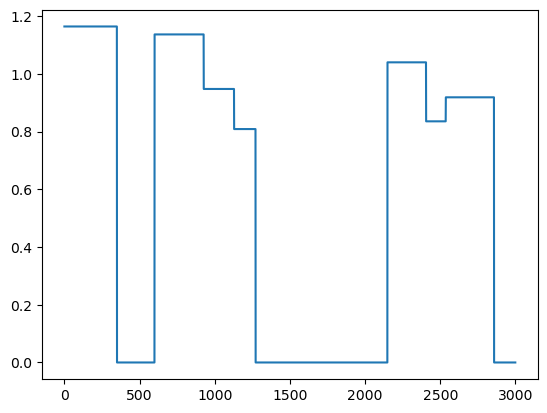

In [13]:
plt.plot(U[0,:])
plt.show()

In [14]:
U.shape

(50, 3000)

In [15]:
X.shape

(50, 3000, 8)

In [16]:
Y.shape

(50, 3000, 8)

In [17]:
X_train.shape

(10, 3000, 8)

In [18]:
U_train.shape

(10, 3000)

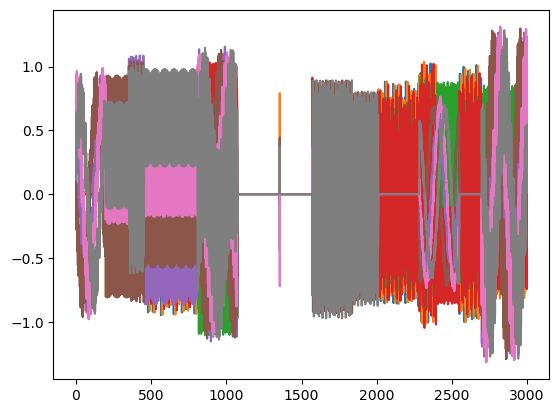

In [19]:
plt.plot(X_train[0,:,:])
plt.show()

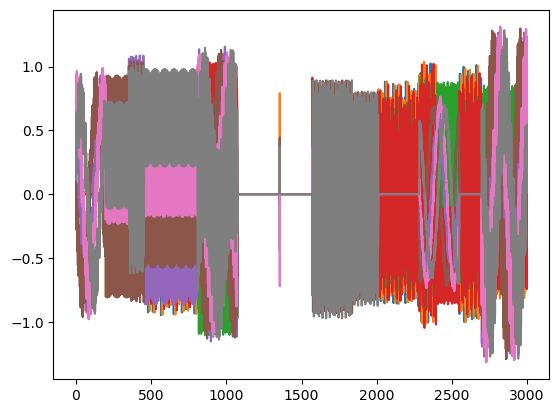

In [20]:
plt.plot(Y_train[0,:,:])
plt.show()

In [21]:
print(f"Is arr NaN? {np.isnan(U)}")

Is arr NaN? [[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [22]:
trial_time_length = 3000

# Fit model

In [23]:
# Define model

latent_dim = 8
n_neurons = Y.shape[2]

# sigma = 1 too high, results in NaNs
_sigma, _kappa, c_period = 0.75, 0.15, 2*jnp.pi #1.0, 0.15, 2*jnp.pi
t_period = trial_time_length + 6 * _kappa
T2_basis_funcs = utils.Tm_basis(5, M_conditions=1, sigma=_sigma, kappa=_kappa, period=jnp.array([t_period, c_period]))
T1_basis_funcs = utils.T1_basis(5, _sigma, _kappa, c_period)

A_prior = WeightSpaceGaussianProcess(T1_basis_funcs, D1=latent_dim, D2=latent_dim)
b_prior = WeightSpaceGaussianProcess(T1_basis_funcs, D1=latent_dim, D2=1)
m0_prior = WeightSpaceGaussianProcess(T1_basis_funcs, D1=latent_dim, D2=1)
C_prior = WeightSpaceGaussianProcess(T1_basis_funcs, D1=n_neurons, D2=latent_dim)
model = CLDS(
    wgps={
        'A': A_prior, 
        'b': b_prior,
        'C': C_prior,
        'm0': m0_prior,
        }, 
    state_dim=latent_dim, 
    emission_dim=n_neurons,
    )



In [24]:
t_period

3000.9

In [25]:
n_neurons

8

0
1
2


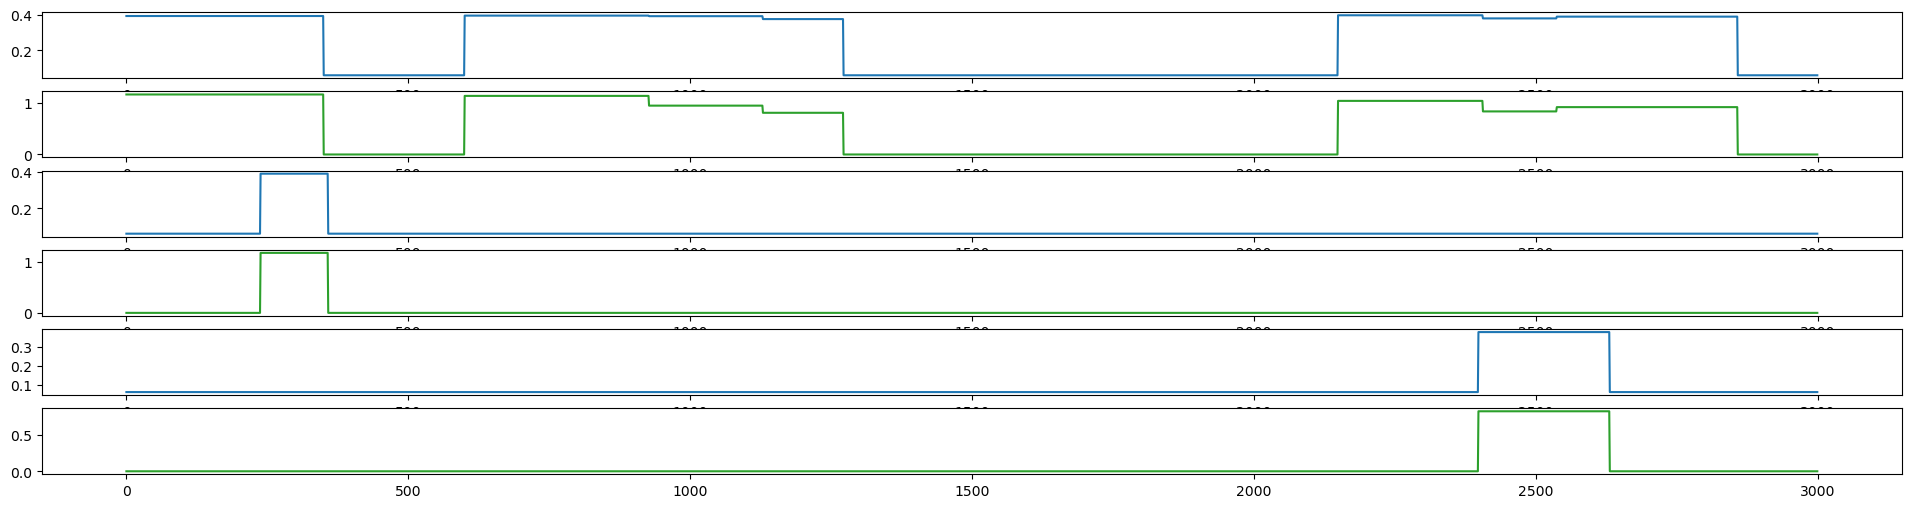

In [26]:

fig, axs = plt.subplots(figsize=[24,6], ncols=1,nrows=6) #2)
for i in range(3):
    print(i)
    axs[i*2 + 0].plot(A_prior.sample(jxr.PRNGKey(3), U[i])[:,0,0], c='tab:blue');
    # axs[i*3 + 1].plot(U[i,:], A_prior.sample(jxr.PRNGKey(3), U[i])[:,0,1], c='tab:orange')
    axs[i*2 + 1].plot(U[i], c='tab:green')
    # axs[1].plot(U[i][:,1], A_prior.sample(jxr.PRNGKey(3), U[i])[:,0,1], '.', c='tab:orange')

In [27]:
# # Initialize A and b weights as ring attractor

# def ring_weights(kappa, sigma):
#     def weight_space_coefficients(m):
#         return jnp.sqrt(utils.squared_exponential_spectral_measure(m, sigma, kappa))

#     # A weights

#     ring_wA_weights = jnp.zeros((len(A_prior.basis_funcs), latent_dim, latent_dim))
#     # A[0,0] = 1/2 - cos(2 t)/2
#     ring_wA_weights = ring_wA_weights.at[11,0,0].set(1/weight_space_coefficients(0) * 1/2)
#     ring_wA_weights = ring_wA_weights.at[15,0,0].set(-1/weight_space_coefficients(2) * 1/2)

#     # A[1,1] = 1/2 + cos(2 t)/2
#     ring_wA_weights = ring_wA_weights.at[11,1,1].set(1/weight_space_coefficients(0) * 1/2)
#     ring_wA_weights = ring_wA_weights.at[15,1,1].set(1/weight_space_coefficients(2) * 1/2)

#     # A[0,1] = -sin(2 t)/2
#     ring_wA_weights = ring_wA_weights.at[14,1,0].set(-1/weight_space_coefficients(2) * 1/2)
#     ring_wA_weights = ring_wA_weights.at[14,0,1].set(-1/weight_space_coefficients(2) * 1/2)

#     # b weights

#     ring_wb_weights = jnp.zeros((len(b_prior.basis_funcs), 2, 1))

#     ring_wb_weights = jnp.zeros((len(b_prior.basis_funcs), b_prior.D1, b_prior.D2)) # len_basis D1 D2
#     ring_wb_weights = ring_wb_weights.at[12,0,0].set(1/weight_space_coefficients(1))
#     ring_wb_weights = ring_wb_weights.at[13,1,0].set(1/weight_space_coefficients(1))

#     return ring_wA_weights, ring_wb_weights

In [28]:
num_timesteps = Y.shape[1]

# ring_wA_weights, ring_wb_weights = ring_weights(_kappa, _sigma)

# Initialize
seed = 2 # use 0 for plotting
A_key, b_key, C_key, m0_key = jxr.split(jxr.PRNGKey(seed), 4)
initial_params = ParamsCLDS(
    dynamics_gp_weights =  A_prior.sample_weights(A_key),# ring_wA_weights, 
    Q = jnp.eye(latent_dim),
    R = jnp.eye(n_neurons),
    m0 = jnp.zeros(latent_dim),
    m0_gp_weights = m0_prior.sample_weights(m0_key),
    S0 = jnp.eye(latent_dim),
    emissions_gp_weights = C_prior.sample_weights(C_key),
    bias_gp_weights = b_prior.sample_weights(b_key),
    Cs = jnp.tile(jxr.normal(C_key, (n_neurons, latent_dim)), (num_timesteps, 1, 1)), #C_prior.sample(C_key, U[0]), #jnp.tile(jxr.normal(C_key, (n_neurons, latent_dim)), (num_timesteps, 1, 1)), #C_prior.sample(C_key, U[0]),
    bs = None, #jnp.zeros((num_timesteps-1, latent_dim)),# None, #b_prior.sample(b_key, U[0]).squeeze(), #jnp.zeros((num_timesteps-1, latent_dim)), #b_prior.sample(b_key, conditions).squeeze(),
)


In [29]:
num_timesteps

3000

  0%|          | 0/200 [00:00<?, ?it/s]

Test log likelihood: -335985.78125


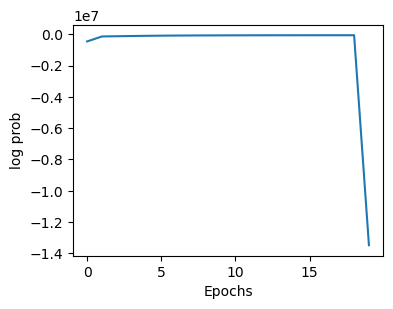

In [30]:

# Fit model
params, log_probs = inference.fit_em(model, initial_params, emissions=Y_train, conditions=U_train, num_iters=200)
test_ll = model.marginal_log_lik(params, emissions=Y_test, conditions=U_test)
print(f"Test log likelihood: {test_ll}")

# Show results
fig, ax = plt.subplots(figsize=[4,3])
ax.plot(log_probs)
ax.set_ylabel('log prob')
ax.set_xlabel('Epochs');

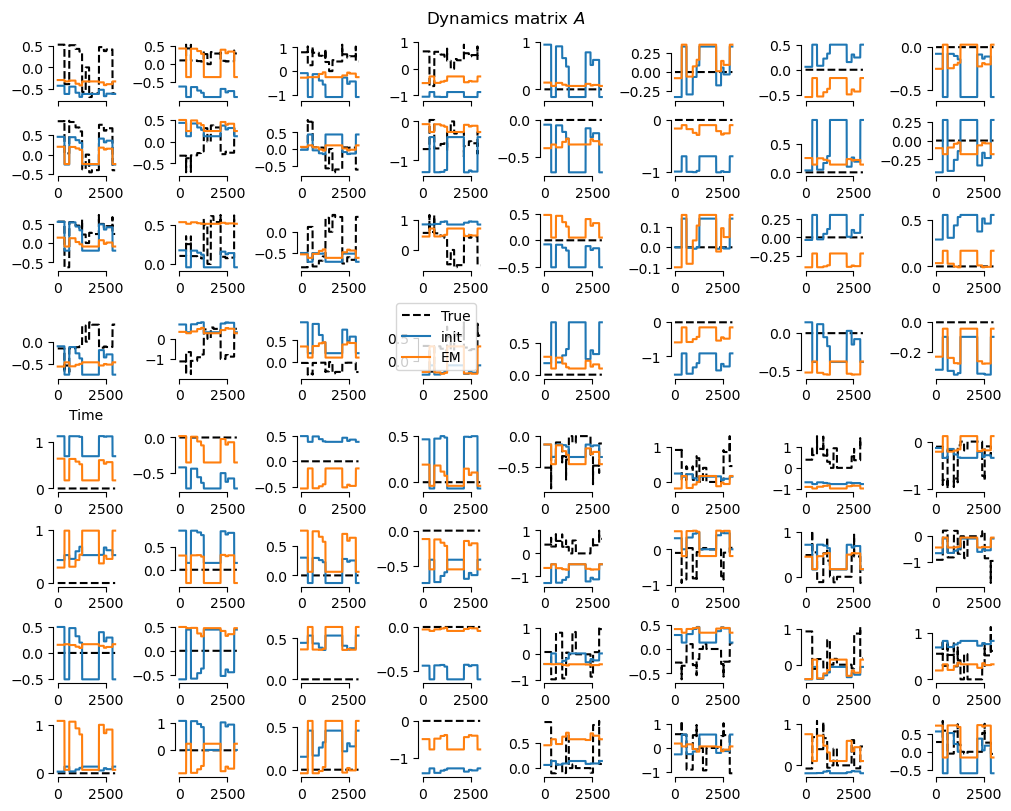

In [31]:
fig, axs = plt.subplots(ncols=latent_dim, nrows=latent_dim, figsize=(10, 8), constrained_layout=True);

for i in range(8):
    for j in range(8):
        ax = axs[i,j]
        # true_As, true_bs, true_Cs = dynamics(theta[0], omega, switchtimeTL[0], switchtimeBR[0])
        ax.plot(trueFC[i,j,:,0], 'k--', label='True')
        ax.plot(A_prior(initial_params.dynamics_gp_weights, U[0][:-1])[:,i,j], label='init')
        ax.plot(A_prior(params.dynamics_gp_weights, U[0][:-1])[:,i,j], label='EM')
        # print(A_prior(params.dynamics_gp_weights, theta[0][:-1]))
        # print(A_prior(params.dynamics_gp_weights, theta[0][:-1]).shape)
        # # ax.set_title(f'A[{i},{j}]')
axs[3,0].set_xlabel('Time')
axs[3,3].legend()

for ax in axs.flatten():
    sns.despine(ax=ax, trim=True, offset=True)
for ax in axs[0]:
    ax.set_xticklabels([])
    
fig.suptitle('Dynamics matrix $A$');


# dictSimulation = {'true_As':true_As, 'true_bs':true_bs, 'true_Cs':true_Cs}
# savemat('dictSimulation.mat',dictSimulation)

In [32]:
dictCLDS   = {'trueFC': trueFC[:,:,:,:],
              'clds': A_prior(params.dynamics_gp_weights, U[0][:])
              }
savemat('cldsoutput_TMLR_last40trials.mat',dictCLDS)


In [33]:
a = A_prior(params.dynamics_gp_weights, U[0][:-1])

In [34]:
a.shape

(2999, 8, 8)

In [35]:
aHat  = A_prior(params.dynamics_gp_weights, U[0][:-1])
xtHat = aHat[0,:,:]@Y_train[0,0,:]

In [36]:
xtHat.shape

(8,)

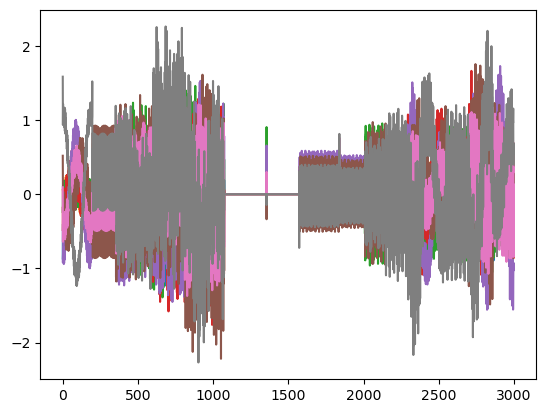

In [37]:
aHat  = A_prior(params.dynamics_gp_weights, U[0][:-1])
xtHat = aHat[0,:,:]@X_train[0,0,:]
xtHatAll = np.zeros([8, 2999])

for i in range(2999):
    xtHatAll[:,i] = aHat[i,:,:]@X_train[0,i,:]

plt.plot(xtHatAll.T)
plt.show()

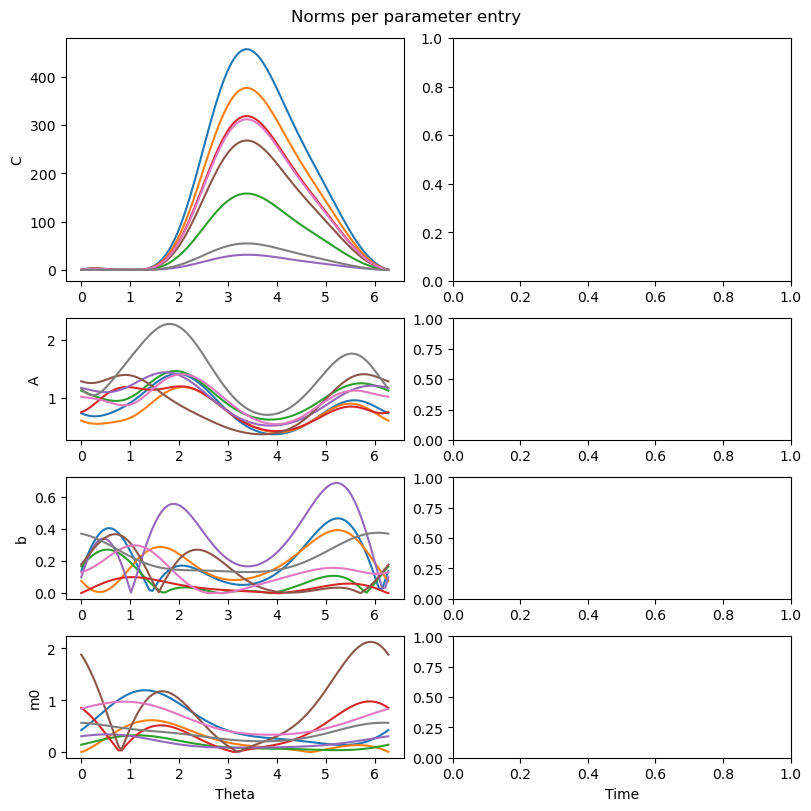

In [38]:
fig, axs = plt.subplots(ncols=2, nrows=4, figsize=[8,8], height_ratios=[2,1,1,1], constrained_layout=True)

thetas = jnp.linspace(0, 2*jnp.pi, 100)
_theta_conditions = jnp.stack([jnp.ones_like(thetas), thetas]).T
# _t_conditions = jnp.stack([bin_edges, jnp.ones(len(bin_edges))]).T

for i, (label, prior, weights) in enumerate(zip(
        ['C', 'A', 'b', 'm0'],
        [C_prior, A_prior, b_prior, m0_prior], 
        [params.emissions_gp_weights, params.dynamics_gp_weights, params.bias_gp_weights, params.m0_gp_weights]
        )):
    params_theta = prior(weights, thetas)
    # params_t = prior(weights, _t_conditions)

    axs[i, 0].plot(thetas, jnp.linalg.norm(params_theta, axis=-1))
    # axs[i, 1].plot(bin_edges, jnp.linalg.norm(params_t, axis=-1))
    axs[i, 0].set_ylabel(label)

axs[-1, 0].set_xlabel('Theta')
axs[-1, 1].set_xlabel('Time')

# axs[0].plot(thetas, jnp.linalg.norm(Cs_theta, axis=-1));
# axs[1].plot(bin_edges, jnp.linalg.norm(Cs_t, axis=-1));
fig.suptitle('Norms per parameter entry')
plt.show()

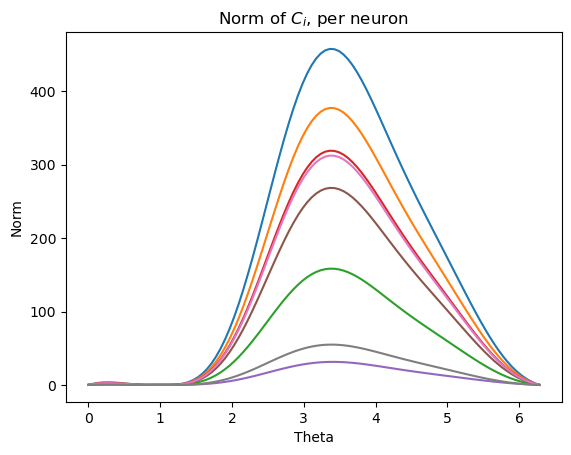

In [39]:
thetas = jnp.linspace(0, 2*jnp.pi, 100)
Cs_theta = C_prior(params.emissions_gp_weights, thetas)
# bs_t = b_prior(params.bias_gp_weights, _t_conditions)

fig, ax = plt.subplots()
ax.plot(thetas, jnp.linalg.norm(Cs_theta, axis=-1))
ax.set_xlabel('Theta')
ax.set_ylabel('Norm')
ax.set_title('Norm of $C_{i}$, per neuron')
# plt.savefig('figures/HD_C_norm_theta.png', dpi=300)
plt.show()

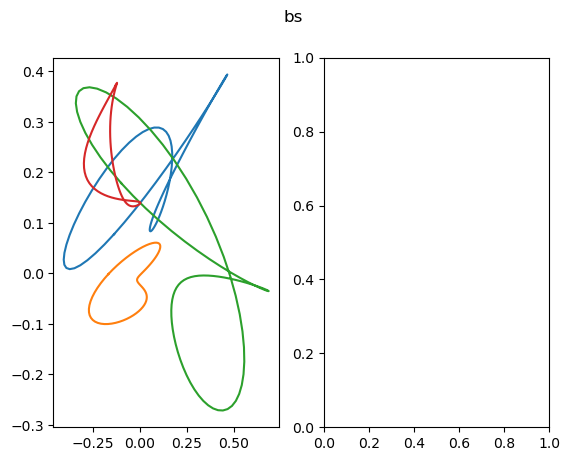

In [40]:
thetas = jnp.linspace(0, 2*jnp.pi, 100)
_theta_conditions = jnp.stack([3*jnp.ones_like(thetas), thetas]).T
# _t_conditions = jnp.stack([bin_edges, jnp.ones(len(bin_edges))]).T
bs_theta = b_prior(params.bias_gp_weights, thetas)
# bs_t = b_prior(params.bias_gp_weights, _t_conditions)

fig, axs = plt.subplots(ncols=2)
axs[0].plot(*bs_theta.squeeze().T);
# axs[1].plot(bin_edges, bs_t.squeeze());
fig.suptitle('bs')
plt.show()

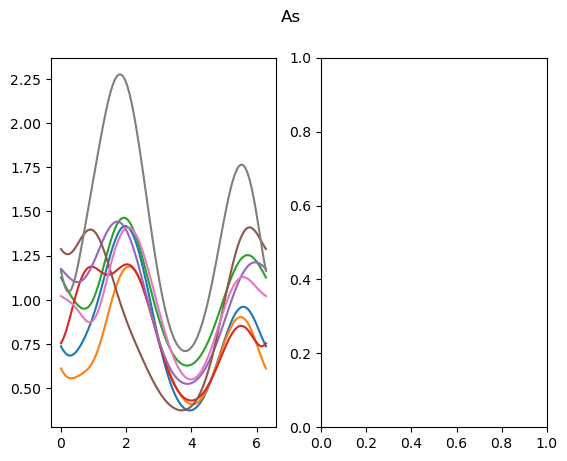

In [41]:
thetas = jnp.linspace(0, 2*jnp.pi, 100)
# _theta_conditions = jnp.stack([3*jnp.ones_like(thetas), thetas]).T
# _t_conditions = jnp.stack([bin_edges, jnp.ones(len(bin_edges))]).T
As_theta = A_prior(params.dynamics_gp_weights, thetas)
# As_t = A_prior(params.dynamics_gp_weights, _t_conditions)

fig, axs = plt.subplots(ncols=2)
axs[0].plot(thetas, jnp.linalg.norm(As_theta, axis=-1));
# axs[1].plot(bin_edges, jnp.linalg.norm(As_t, axis=-1));
fig.suptitle('As')
plt.show()

NameError: name 'bin_edges' is not defined

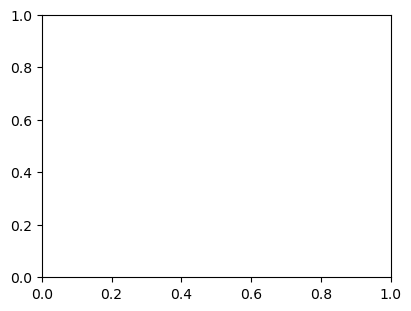

In [42]:
def reconstruct_y(b):
    _, (filtered_means, _), (smoothed_means, smoothed_covs, _) = model.smoother(params, Y[b], U[b])
    Cs = C_prior(params.emissions_gp_weights, U[b])
    _reconstructed_ys = jnp.einsum('tnl,tl->tn', Cs, smoothed_means)
    return _reconstructed_ys

reconstructed_ys = jax.vmap(reconstruct_y)(jnp.arange(len(Y)))
fig, ax = plt.subplots(figsize=[4,3], constrained_layout=True);
for i in range(n_neurons):
    ax.plot(bin_edges, Y.mean(0)[:,i], c='k', alpha=1.0)
    ax.plot(bin_edges, reconstructed_ys.mean(0)[:,i], c='tab:orange', alpha=1.0)
    # ax.fill_between(
    #     bin_edges,
    #     reconstructed_ys.mean(0)[:,i] - reconstructed_ys.std(0)[:,i], 
    #     reconstructed_ys.mean(0)[:,i] + reconstructed_ys.std(0)[:,i], 
    #     color='tab:orange', alpha=0.3)

# ax.plot(Y.mean(0).mean(1), c='k', label='Data')
# ax.plot(reconstructed_ys.mean(0).mean(1), c='tab:orange', label='Model')

ax.set_ylabel('Firing rate')
ax.set_title('Reconstruction')

lines = [plt.Line2D([0], [0], color='k', lw=2), plt.Line2D([0], [0], color='tab:orange', lw=2)]
ax.legend(lines, ['Data', 'Model'])
ax.set_xlabel('Time (s)');
# plt.savefig(f'figures/headdirection_reconstruction.eps', format='eps')

In [ ]:
all_smoothed_means = jax.vmap(lambda b: model.smoother(params, Y[b], U[b])[2][0])(jnp.arange(len(Y)))
all_smoothed_means.shape

In [ ]:
all_smoothed_means = jax.vmap(lambda b: model.smoother(params, Y[b], U[b])[2][0])(jnp.arange(len(Y)))
theta_range = jnp.linspace(0, 2*jnp.pi, 10)

# Bin U into the theta_range bins
U_digit = jnp.digitize(U, theta_range)

# Print mean x per bin
mean_x_per_bin = jnp.array([all_smoothed_means[U_digit == i].mean(0) for i in range(0, len(theta_range))])

plt.plot(theta_range, mean_x_per_bin)
plt.xlabel('Theta')
plt.ylabel('Mean x')

In [ ]:
sns.set_style('white')

num_theta_bins = 50

thetas = jnp.linspace(0, 2*jnp.pi, num_theta_bins)

# E[x | theta]

all_smoothed_means = jax.vmap(lambda b: model.smoother(params, Y[b], U[b])[2][0])(jnp.arange(len(Y)))
U_digit = jnp.digitize(U, thetas)
mean_x_per_bin = jnp.array([all_smoothed_means[U_digit == i].mean(0) for i in range(0, len(thetas))])
print(mean_x_per_bin.shape)

# Tuning curves
tuning_curves = nap.compute_1d_tuning_curves(
                    group=spikes_adn,
                    feature=angle,
                    nb_bins=num_theta_bins,
                    ep = epochs['wake'],
                    minmax=(0, 2 * jnp.pi)
                    )

tuning_curves = jnp.array([tuning_curves[u] for u in tuning_curves.keys()])
tuning_norm_sorted = jnp.argsort(jnp.linalg.norm(tuning_curves, axis=-1))[::-1]

reds = plt.get_cmap('Reds')

_U, _S, _ = jnp.linalg.svd(params.Q)
H = jnp.linalg.pinv(jnp.diag(jnp.sqrt(_S))) @ _U.T

Cs = C_prior(params.emissions_gp_weights, thetas)

Cx = jnp.einsum('bni,bi->bn', Cs, mean_x_per_bin)

fig, axs = plt.subplots(figsize=[10,2], ncols=4, constrained_layout=True)
axs = axs.flatten()

for i, j in enumerate(tuning_norm_sorted[:len(axs)]):
    axs[i].plot(thetas, tuning_curves[j], c='tab:blue', label='Empirical');
    axs[i].tick_params(axis='y', colors='tab:blue')
    ax2 = axs[i].twinx()
    sns.despine(fig, ax2, left=True, top=True, right=True)

    # for t in [1]:
        # _conditions = jnp.stack([t*jnp.ones_like(thetas), thetas]).T
    # Cs = jnp.einsum('tij,jn->tin', Cs, H)

    # C_norm_sorted = jnp.argsort(jnp.linalg.norm(jnp.linalg.norm(Cs, axis=-1), axis=0))[::-1]
    
    # ax2.plot(thetas, jnp.square(jnp.linalg.norm(Cs, axis=-1))[:,j], c='tab:red', zorder=-1, label=r'$||C(\theta)_n||$'); # c=reds(t/len(bin_edges[::20])),
    ax2.plot(thetas, jnp.square(Cx[:,j]), c='tab:red', label='Model')
    # Color ax
    # ax2.spines['left'].set_color('tab:blue')
    ax2.tick_params(axis='y', colors='tab:red')
    axs[i].set_title(f'Unit {j}')

# Add legend
lines = [axs[0].lines[0], ax2.lines[0]]
labels = [l.get_label() for l in lines]
axs[0].legend(lines, labels)

for ax in axs:
    sns.despine(ax=ax)

# fig.suptitle(r'Empirical tuning curves v.s. emission tuning for top 4 units')

# for ax in axs:
#     sns.despine(ax=ax, trim=True, offset=5)

# axs[1].set_title(r'Norm of $C(\theta)$, per neuron')
# axs[0].set_title('True tuning curves')
# axs[1].set_xlabel(r'$\theta$')
# axs[0].legend()
# plt.savefig('figures/HD_tuning_curves.eps', format='eps')

In [ ]:
# smoothed_means = jax.vmap(lambda b: model.smoother(params, Y[b], U[b])[2][0])(jnp.arange(len(Y)))
# plt.plot(*smoothed_means.mean(0).T);

# eigvals, eigvecs = jnp.linalg.eig(A_prior(params.dynamics_gp_weights, U[1]).mean(0))

_U, _S, _ = jnp.linalg.svd(params.Q)
H = jnp.linalg.pinv(jnp.diag(jnp.sqrt(_S))) @ _U.T

def angle_to_color(theta):
    norm_theta = theta / (2 * jnp.pi)  # Normalize theta to [0, 1]
    return plt.cm.viridis(norm_theta)

for b in range(len(Y))[:20]:
    x_hat = model.smoother(params, Y[b], U[b])[2][0]
    x_hat = jnp.einsum('ij,tj->ti', H, x_hat)
    plt.plot(*x_hat.T, '.', alpha=0.2, color=angle_to_color(U[b][0]))
plt.title('Smoothed latent states')
    # plt.plot(U[b][:,1], x_hat[:,0], '.', alpha=0.3)

# # Plot eigenvectors
# plt.arrow(0, 0, eigvecs[0,0].real, eigvecs[0,1].real, color='r', head_width=0.1)
# plt.arrow(0, 0, eigvecs[1,0].real, eigvecs[1,1].real, color='r', head_width=0.1)

In [ ]:
# plt.plot(A_prior(params.dynamics_gp_weights, U[1])[:,0]);
# plt.plot(A_prior(params.dynamics_gp_weights, U[1])[:,1]);
sns.set_style('white')
thetas = jnp.linspace(0, 2*jnp.pi, 200)
bs_theta = b_prior(params.bias_gp_weights, thetas).squeeze()
As_theta = A_prior(params.dynamics_gp_weights, thetas)

def get_angles(vs, correction=0):
    angles = jnp.arctan2(vs[:,1], vs[:,0]) + correction
    return jnp.where(angles < 0, angles + 2*jnp.pi, angles)

# Rotate first

_U, _S, _ = jnp.linalg.svd(params.Q)
H = jnp.linalg.pinv(jnp.diag(jnp.sqrt(_S))) @ _U.T
Hinv = _U @ jnp.diag(jnp.sqrt(_S))

bs_theta_rot = jnp.einsum('ij,tj->ti', H, bs_theta)
As_theta_rot = jnp.einsum('ij,tjk,kl->til', H, As_theta, Hinv)

# Plot 
eigvals, eigvecs = jnp.linalg.eig(As_theta_rot)

top_eigenval = jnp.where(eigvals.real[:,0] > eigvals.real[:,1], eigvals.real[:,0], eigvals.real[:,1])
bottom_eigenval = jnp.where(eigvals.real[:,0] < eigvals.real[:,1], eigvals.real[:,0], eigvals.real[:,1])

# Calculate angle of vector
angles_1 = get_angles(eigvecs[:,:,0].real)
angles_2 = get_angles(eigvecs[:,:,1].real)

top_eigvec_angles = jnp.where(top_eigenval == eigvals.real[:,0], angles_1, angles_2)
bottom_eigvec_angles = jnp.where(bottom_eigenval == eigvals.real[:,0], angles_1, angles_2) 

# angles_1 = jnp.where(angles_1 < 0, angles_1 + 2*jnp.pi, angles_1)
# angles_2 = jnp.where(angles_2 < 0, angles_2 + 2*jnp.pi, angles_2)

fig, ax = plt.subplots(figsize=[3,2], constrained_layout=True)
ax.plot(thetas, top_eigenval, label='Eig. val. 1')
ax.plot(thetas, bottom_eigenval, label='Eig. vec. 2')
ax.axhline(1,  c='tab:grey', ls='--', zorder=-1)
ax.axhline(0, c='tab:grey', ls='--', zorder=-1)
ax.legend()
ax.set_title('Eigenvalues')

# shift = 0.6

# axs[1].plot(thetas, (top_eigvec_angles + shift )  % jnp.pi, '.', c='tab:blue')
# # axs[1].plot(thetas, top_eigvec_angles % jnp.pi, '.', c='tab:blue')
# # axs[1].plot(thetas, angles_1+jnp.pi, '.', c='tab:blue')
# axs[1].plot(thetas, (bottom_eigvec_angles + shift) % jnp.pi, '.', c='tab:orange')
# # axs[1].plot(thetas, angles_2+jnp.pi, '.', c='tab:orange')
# axs[1].set_title('Eigenvector angles')
# axs[1].set_ylabel('absolute Angle (rad)')
# # db_theta = jnp.diff(bs_theta.squeeze(), axis=0)/(thetas[1] - thetas[0])
# # db_theta_angles = jnp.arctan2(db_theta[:,1], db_theta[:,0])
# # db_theta_angles = jnp.where(db_theta_angles < 0, db_theta_angles + 2*jnp.pi, db_theta_angles)
# # axs[2].plot(db_theta_angles, '.')
# b_theta_angles = get_angles(bs_theta_rot)
# b_theta_angles = jnp.where(b_theta_angles < 0, b_theta_angles + 2*jnp.pi, b_theta_angles) # Correct for negative angles

# axs[1].plot(thetas, (b_theta_angles + shift) % jnp.pi, '.', c='k', label='Angle of bias')
# axs[1].legend()

# for ax in axs:
ax.set_xlabel(r'Head direction ($\theta$)')
sns.despine(ax=ax)

# plt.savefig('figures/HD_eigvals_angles.eps')

In [ ]:
cmap = plt.cm.twilight_shifted
# Fixed points 

thetas = jnp.linspace(0, 2*jnp.pi, 100)
colors = cmap(thetas/(2*jnp.pi))
As_theta = A_prior(params.dynamics_gp_weights, thetas)
bs_theta = b_prior(params.bias_gp_weights, thetas).squeeze()

# Rotate

_U, _S, _ = jnp.linalg.svd(params.Q)
H = jnp.linalg.pinv(jnp.diag(jnp.sqrt(_S))) @ _U.T
Hinv = _U @ jnp.diag(jnp.sqrt(_S))

bs_theta_rot = jnp.einsum('ij,tj->ti', H, bs_theta)
As_theta_rot = jnp.einsum('ij,tjk,kl->til', H, As_theta, Hinv)


fixed_points = jax.vmap(lambda t: jax.scipy.linalg.solve(jnp.eye(latent_dim) - As_theta_rot[t], bs_theta_rot[t]))(jnp.arange(len(thetas)))


# for i, fp in enumerate(fixed_points):
#     ax.scatter(*fp, color=colors[i])

pad = 1.0
x_lims = (jnp.amin(fixed_points[:,0])-pad, jnp.amax(fixed_points[:,0])+pad)
y_lims = (jnp.amin(fixed_points[:,1])-pad, jnp.amax(fixed_points[:,1])+pad)

def plot_vector_field(A, ax, center=jnp.zeros((2,)), color='k'):
    x = jnp.linspace(*x_lims, 8)
    y = jnp.linspace(*y_lims, 8)
    X, Y = jnp.meshgrid(x, y)
    U = A[0, 0] * (X - center[0]) + A[0, 1] * (Y - center[1])
    V = A[1, 0] * (X - center[0]) + A[1, 1] * (Y - center[1])

    # Thicken the arrows
    ax.quiver(X, Y, U, V, units='width', scale=15, width=0.015, color=color)

sns.set_style('white')
fig = plt.figure(figsize=[10,3.5], constrained_layout=True)

# Make a 5 x 2 gridspec, and make the second row one long ax
ncols = 5
gs = fig.add_gridspec(1, ncols, wspace=0.1)
axs = [fig.add_subplot(gs[0, i]) for i in range(ncols)]
# ax1 = fig.add_subplot(gs[1, :])

indices = jnp.linspace(0, len(fixed_points), len(axs), endpoint=False, dtype=int)
for i, ax in zip(indices, axs):
    ax.scatter(*fixed_points[i], color=colors[i], edgecolors='k')
    ax.plot(*fixed_points.T, c='k', alpha=0.2, zorder=-1)
    plot_vector_field(As_theta_rot[i] - jnp.eye(2), ax=ax, center=fixed_points[i], color=colors[i])

for ax in axs:
    if ax is not axs[0]:
        ax.set_yticklabels([])
    ax.set_xlim(*x_lims)
    ax.set_ylim(*y_lims)
    ax.set_aspect('equal')

# Add colorbar
norm = plt.Normalize(0, 2*jnp.pi)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axs, orientation='horizontal', label=r'$\theta$', aspect=50) # shrink=1.0

fig.suptitle('Dynamics around fixed points')
plt.savefig('figures/HD_dynamics_fixed_points.eps')
plt.show()

fig, ax = plt.subplots(figsize=[3,3])
for i, fp in enumerate(fixed_points):
    ax.scatter(*fp, color=colors[i])
ax.set_title('Fixed points')
plt.savefig('figures/HD_fixed_points.png', dpi=300)
plt.show()

# ax1.plot(thetas, fixed_points, c='k');

# plt.plot(fixed_points.T);
# plt.plot(*bs_theta_rot.T);

# def angle_to_color(theta):
#     norm_theta = theta / (2 * jnp.pi)  # Normalize theta to [0, 1]
#     return plt.cm.twilight(norm_theta)

# for b in range(len(Y))[:10]:
#     x_hat = model.smoother(params, Y[b], U[b])[2][0]
#     x_hat = jnp.einsum('ij,tj->ti', H, x_hat)
#     plt.plot(*x_hat.T, '.', alpha=0.2, color=angle_to_color(U[b][0]))

In [ ]:
cmap = plt.cm.twilight

def plot_vector_field(A, ax, color='k'):
    x = jnp.linspace(-1, 1, 6)
    y = jnp.linspace(-1, 1, 6)
    X, Y = jnp.meshgrid(x, y)
    U = A[0, 0] * X + A[0, 1] * Y
    V = A[1, 0] * X + A[1, 1] * Y

    # Thicken the arrows
    ax.quiver(X, Y, U, V, units='width', scale=4, width=0.02, color=color)


t = bin_edges[-1]
thetas = jnp.linspace(0, 2*jnp.pi, 100)
As_theta = A_prior(params.dynamics_gp_weights, thetas)
# _theta_conditions = jnp.stack([t * jnp.ones_like(thetas), thetas]).T

fig, axs = plt.subplots(ncols=5, figsize=[5,3], constrained_layout=True)
colors = cmap(jnp.linspace(0, 1, len(axs), endpoint=False))
indices = jnp.linspace(0, len(thetas), len(axs), endpoint=False).astype(int)
for i, j in enumerate(indices):
    plot_vector_field(As_theta[j] - jnp.eye(latent_dim), axs[i], color=colors[i])
    # axs[i].set_title(r'$\theta=$'+f'{thetas[j]:.2f}')

# Add colorbar
norm = plt.Normalize(0, 2*jnp.pi)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axs, orientation='horizontal', label=r'$\theta$', shrink=0.9, aspect=40)

for ax in axs:
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
# plt.savefig('figures/HD_vector_fields_theta.png', format='png', dpi=300)
plt.show()

bs_theta = b_prior(params.bias_gp_weights, thetas).squeeze()
# bs_theta = jnp.einsum('ij,tj->ti', H, bs_theta)

fig, ax = plt.subplots(figsize=[5,2], constrained_layout=True)
ax.plot(thetas, bs_theta[:,0], label='$b_1$')
ax.plot(thetas, bs_theta[:,1], label='$b_2$')
ax.legend()
ax.set_xlabel('Theta')
ax.set_ylabel('Bias')
ax.grid(False)
sns.despine(ax=ax, offset=5, trim=True)
# plt.savefig('figures/HD_bias.png', format='png', dpi=300)
plt.show()
# for i, index in enumerate(indices):
#     ax.plot(*bs_theta[index], 'o', color=colors[i])
# ax.set_aspect('equal')


# sns.despine(ax=ax, offset=5, trim=True)

In [ ]:
import postprocessing

theta_range = jnp.linspace(0, 2*jnp.pi, 100)

# Compute composite dynamics
x_bin_edges, y_bin_edges, composite_Fs, U_per_bin, bin_counts = postprocessing.compute_composite_dynamics(
    model, params, theta_range, Y_train, U_train, n_bins=15
)

# Compute fixed points
fixed_points = postprocessing.get_fixed_points(model, params, theta_range, ROTATE=True)

In [ ]:
# plot composite dynamics
sns.set_style('white')
cmap = plt.cm.twilight
colors = cmap(jnp.linspace(0,2*jnp.pi,len(fixed_points))/(2*jnp.pi))
cmap_count = plt.cm.Greys
norm_count = plt.Normalize(-0.1, 0.2)

fig, ax = plt.subplots(figsize=[5,4], constrained_layout=True);
ax.quiver(
    *jnp.meshgrid(x_bin_edges, y_bin_edges), *composite_Fs,
    bin_counts.T/jnp.amax(bin_counts), cmap=cmap_count, norm=norm_count, 
    scale=10, width=0.005
    )

for i, fp in enumerate(fixed_points):
    ax.scatter(*fp, color=colors[i])
ax.set_aspect('equal')

# Color of quiver is set by count, lighter means less count (thus more uncertain about calculation)
sm_count = plt.cm.ScalarMappable(cmap=cmap_count, norm=norm_count)
cbar_quiver = plt.colorbar(sm_count, ax=ax, orientation='vertical')
cbar_quiver.set_label('Count')

# Add colorbar for scatter
norm = plt.Normalize(0, 2*jnp.pi)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar_scatter = plt.colorbar(sm, ax=ax, orientation='vertical')
cbar_scatter.set_label(r'$\theta$')
# plt.savefig("figures/HD_activity_fixedpoints_flowfield_2.eps", format='eps')